# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Data load

In [2]:
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

# Preprocessing

In [4]:
# Drop columns with single values
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours'], axis=1)

In [5]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,7,1,...,3,4,1,6,3,3,2,2,2,2


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Find Best Number of Clusters (Elbow Method)

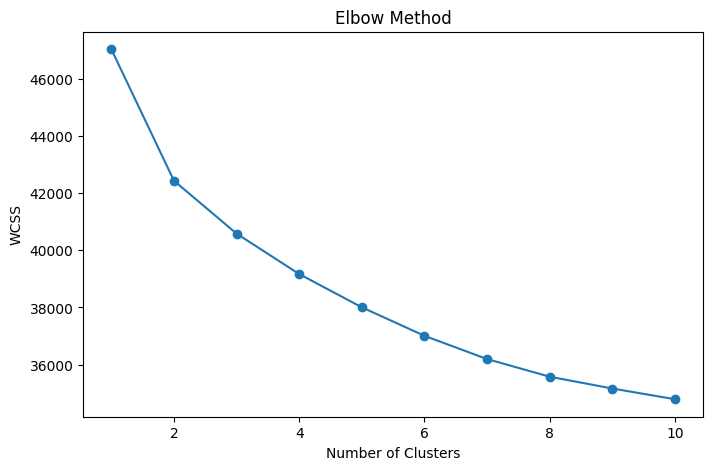

In [7]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Train KMeans Model

In [8]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['Cluster'] = clusters

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Cluster
0,41,1,2,1102,2,1,2,1,1,2,...,1,0,8,0,1,6,4,0,5,1
1,49,0,1,279,1,8,1,1,2,3,...,4,1,10,3,3,10,7,1,7,1
2,37,1,2,1373,1,2,2,4,4,4,...,2,0,7,3,3,0,0,0,0,1
3,33,0,1,1392,1,3,4,1,5,4,...,3,0,8,3,3,8,7,3,0,1
4,27,0,2,591,1,2,1,3,7,1,...,4,1,6,3,3,2,2,2,2,1


# Silhouette Score
>It measures how well-separated the clusters are.

In [9]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters)
print('Silhouette Score:', score)

Silhouette Score: 0.11256945937569668


# PCA for 2D Visualization

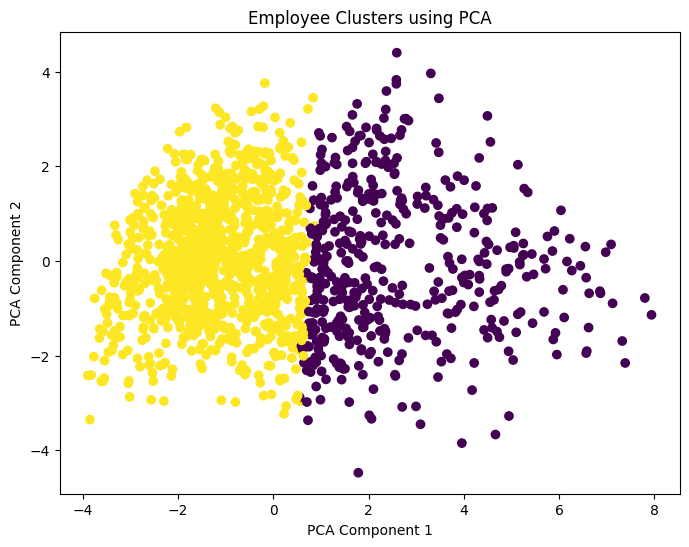

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_components[:,0], pca_components[:,1], c=clusters)
plt.title('Employee Clusters using PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# Cluster Analysis

In [11]:
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

               Age  Attrition  BusinessTravel   DailyRate  Department  \
Cluster                                                                 
0        42.871460   0.082789        1.612200  797.191721    1.291939   
1        34.223541   0.196835        1.605341  804.889219    1.246291   

         DistanceFromHome  Education  EducationField  EmployeeNumber  \
Cluster                                                                
0                8.969499   3.067538        2.204793     1004.409586   
1                9.293769   2.842730        2.267062     1034.152324   

         EnvironmentSatisfaction  ...  PerformanceRating  \
Cluster                           ...                      
0                       2.790850  ...           3.152505   
1                       2.690406  ...           3.154303   

         RelationshipSatisfaction  StockOptionLevel  TotalWorkingYears  \
Cluster                                                                  
0                        2.74

# Attrition Distribution in Clusters

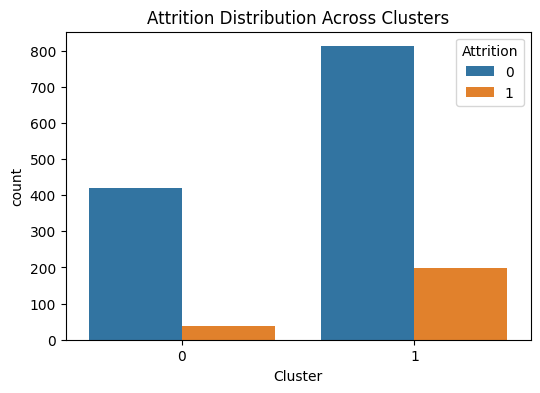

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', hue='Attrition', data=df)
plt.title('Attrition Distribution Across Clusters')
plt.show()

# Graph for Better Grading


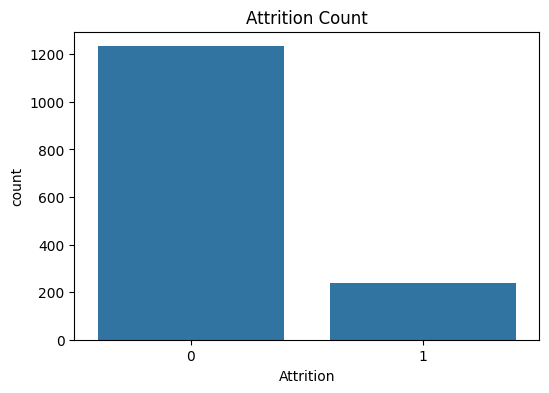

In [13]:
plt.figure(figsize=(6,4))   #Attrition Count
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Count')
plt.show()

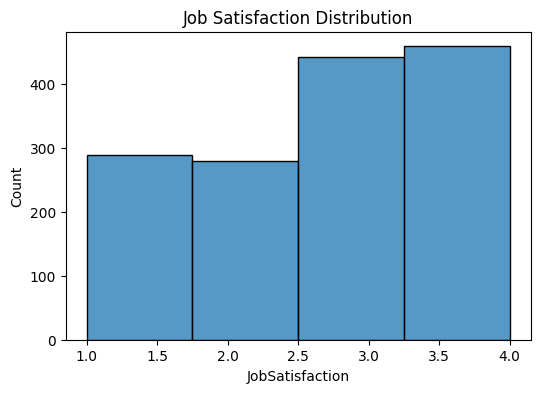

In [14]:
plt.figure(figsize=(6,4))  #Job Satisfaction Distribution
sns.histplot(df['JobSatisfaction'], bins=4)
plt.title('Job Satisfaction Distribution')
plt.show()

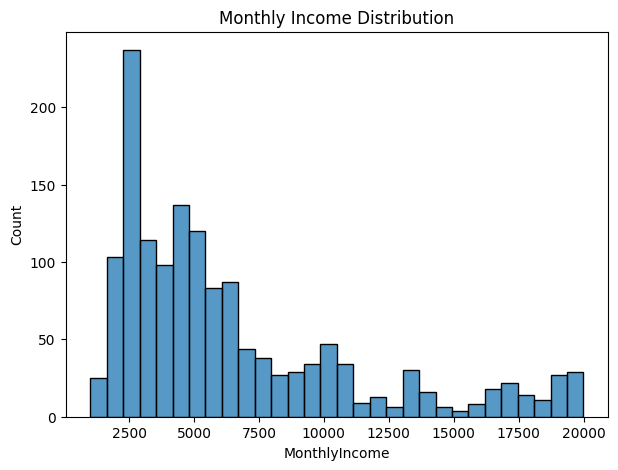

In [15]:
plt.figure(figsize=(7,5))   #Monthly Income Distribution
sns.histplot(df['MonthlyIncome'], bins=30)
plt.title('Monthly Income Distribution')
plt.show()

# Correlation Heatmap

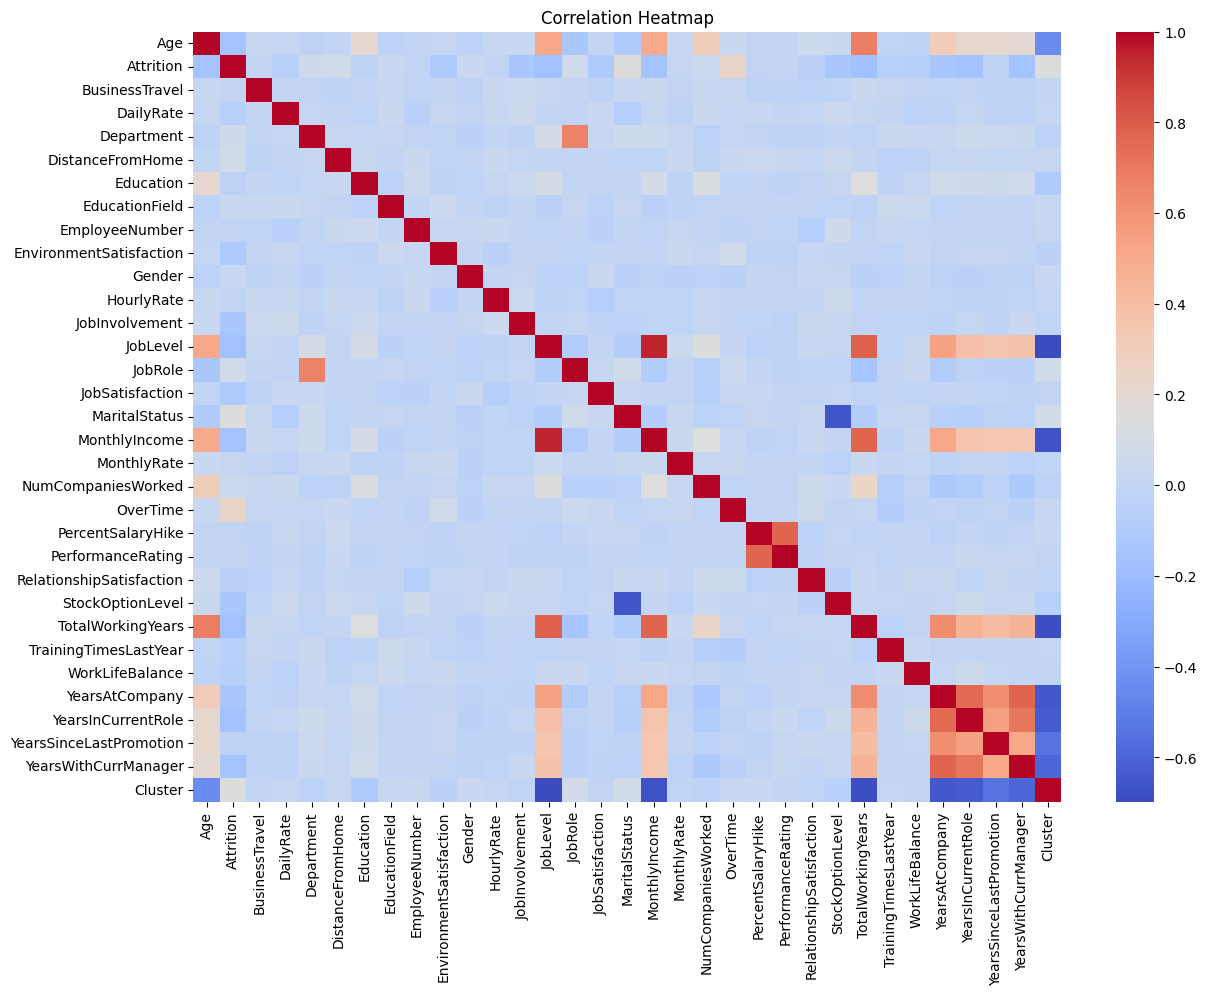

In [16]:
plt.figure(figsize=(14,10))   
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Conclusion
In this project, we used KMeans Clustering
to group employees based on HR factors.
The model helps identify employee groups
that may have higher attrition risk.